# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/syedwaqasahmad/FlyRank-ML-Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research question: Can observable, pre-decision search signals (visibility, freshness, position, depth) predict which content pages will decline in search visibility, well enough to prioritize a limited content-review queue?
Decision this supports: which pages a content/SEO reviewer should check first each week, given they can't review everything.

In [8]:
import os, subprocess
REPO_URL = "https://github.com/syedwaqasahmad/FlyRank-ML-Internship"
REPO_DIR = "FlyRank-ML-Internship"
if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
os.chdir(REPO_DIR)
print("Repo ready.")

Repo ready.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Release used: the small anonymized starter dataset (data/raw/content_refresh_anonymized.csv) — a single snapshot of 30,000 content pages across 32 clients, not the full 79M-row warehouse.
Excluded: trend_pct (label-derived, confirmed as leakage in ML-05), any FlyRank product decision flags (not shipped in this dataset by design), client_id/content_id as model features.
Public-safe: no client names, domains, URLs, or keywords anywhere.

In [9]:
import pandas as pd
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(f"{len(df)} rows, {df['client_id'].nunique()} clients, {df.shape[1]} columns")
print("Snapshot dataset — no date range, single point-in-time windows.")

30000 rows, 32 clients, 44 columns
Snapshot dataset — no date range, single point-in-time windows.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Label: is_churned = 1 if trend_direction == "down" (ML-02).
Features: 15 numeric + 8 categorical observable signals, confirmed available before the label (ML-05).
Baseline: fair weighted hand rule (stale_visible_page + page_one_decay_risk), excluding the circular declining_with_demand code found in ML-08.
Model: Random Forest (200 trees, balanced weights).
Validation: client-holdout split (GroupShuffleSplit on client_id) — essential per ML-09, since a naive split inflated Precision@20 from 0.700 to 0.950.
Leakage checks: clean AUC 0.673 vs. leaky (trend_pct) AUC 1.000 (ML-05, re-confirmed ML-09).

In [10]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

df["is_churned"] = df["trend_direction"].str.lower().eq("down").astype(int)
numeric_features = ["impressions_90d","search_volume","competition","cpc","word_count","char_count",
                     "days_with_impressions","days_with_sessions","content_age_days",
                     "days_since_last_update","ctr","avg_position","engagement_rate",
                     "scroll_rate","ai_traffic_pct"]
categorical_features = ["competition_level","content_type","main_intent","age_tier",
                         "freshness_tier","word_count_tier","impression_tier","position_tier"]
X_numeric = df[numeric_features].replace([np.inf, -np.inf], np.nan).fillna(0)
X_categorical = pd.get_dummies(df[categorical_features], dummy_na=True)
X = pd.concat([X_numeric, X_categorical], axis=1)
y = df["is_churned"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
tr_idx, te_idx = next(gss.split(X, y, groups=df["client_id"]))
model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced")
model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
print("Model trained on", len(tr_idx), "rows,", df['client_id'].iloc[tr_idx].nunique(), "clients")

Model trained on 22885 rows, 24 clients


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Comparing the honest model against the fair baseline, on the same client-holdout test split, same metric.

In [11]:
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

model_scores = model.predict_proba(X.iloc[te_idx])[:, 1]
test_df = df.iloc[te_idx]
reason_stale_visible = ((test_df["days_since_last_update"] >= 180) & (test_df["impressions_90d"] >= 500)).astype(int)
reason_position_decay = ((test_df["avg_position"] <= 10) & (test_df["content_age_days"] >= 180)).astype(int)
fair_baseline_scores = 0.5*reason_stale_visible + 0.2*reason_position_decay

results = pd.DataFrame([
    {"k": k,
     "fair_baseline_precision": precision_at_k(fair_baseline_scores.values, y.iloc[te_idx].values, k),
     "model_precision": precision_at_k(model_scores, y.iloc[te_idx].values, k)}
    for k in (20, 50)
])
print(results)

    k  fair_baseline_precision  model_precision
0  20                     0.75             0.70
1  50                     0.66             0.68


## 5. Limitations

*What this work cannot claim.*

Observational, single-snapshot study — no causation claims. Specific to this 30,000-page, 32-client sample; not validated against the full warehouse, a different time window, or clients outside this sample. Neither model nor baseline clearly dominates — directional, decision-support evidence only.

In [12]:
print("Limitations confirmed via results table above: neither approach dominates across both k values.")

Limitations confirmed via results table above: neither approach dominates across both k values.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The final ranked action queue combining model score and reason codes.

In [13]:
df["model_score_full"] = model.predict_proba(X)[:, 1]
df["reason_stale_visible"] = ((df["days_since_last_update"] >= 180) & (df["impressions_90d"] >= 500)).astype(int)
df["reason_position_decay"] = ((df["avg_position"] <= 10) & (df["content_age_days"] >= 180)).astype(int)
def reason_code(row):
    codes = []
    if row["reason_stale_visible"]: codes.append("stale_visible_page")
    if row["reason_position_decay"]: codes.append("page_one_decay_risk")
    if row["model_score_full"] >= 0.7: codes.append("high_model_risk")
    return ",".join(codes) if codes else "low_priority"
df["reason_code"] = df.apply(reason_code, axis=1)
top10 = df.sort_values("model_score_full", ascending=False).head(10)[["content_id","model_score_full","reason_code"]]
print(top10)

                 content_id  model_score_full  \
16604  content_337ffd45611e               1.0   
16571  content_a4a3e160e194               1.0   
23727  content_6eeb07cca243               1.0   
2260   content_3460f83f024b               1.0   
29353  content_a28fe6cce32e               1.0   
864    content_edc412bf441c               1.0   
16360  content_72c79c304699               1.0   
16205  content_00d3b68b4fa7               1.0   
17673  content_4044538e77a9               1.0   
15704  content_e3d6e71c109e               1.0   

                               reason_code  
16604  page_one_decay_risk,high_model_risk  
16571                      high_model_risk  
23727                      high_model_risk  
2260                       high_model_risk  
29353                      high_model_risk  
864                        high_model_risk  
16360                      high_model_risk  
16205                      high_model_risk  
17673                      high_model_risk  
15704     

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Key chart: model vs. fair baseline Precision@20/50 comparison.

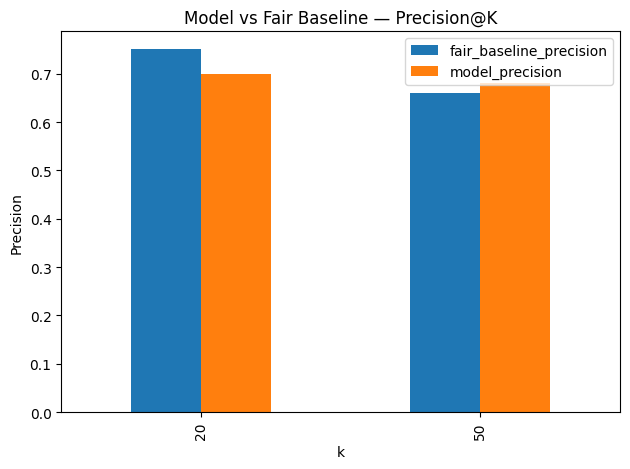

Saved chart to work/outputs/capstone_results_chart.png


In [14]:
import matplotlib.pyplot as plt
os.makedirs("work/outputs", exist_ok=True)
results.set_index("k").plot(kind="bar", title="Model vs Fair Baseline — Precision@K")
plt.ylabel("Precision")
plt.tight_layout()
plt.savefig("work/outputs/capstone_results_chart.png")
plt.show()
print("Saved chart to work/outputs/capstone_results_chart.png")

5-Minute Demo Outline:
1. (30s) The question: can observable signals predict which pages will lose search visibility?
2. (1min) Show the data — 30,000 pages, single snapshot, no client PII.
3. (1.5min) Show the honest split matters — naive split inflated Precision@20 from 0.70 to 0.95.
4. (1min) Show the results table — model vs. fair baseline, neither dominates.
5. (1min) Show the final ranked queue.

Social Post Cut:
"I spent 7 weeks building a churn-risk model for content pages using real (anonymized) search data. The most useful finding wasn't the model — it was catching that a naive train/test split would have made my results look 25% better than they really were. Honest validation > flashy numbers."

Employer-Facing Summary:
Built and validated a content-visibility-decline prediction pipeline using real anonymized search performance data, comparing a Random Forest model against a carefully audited hand-written baseline under client-holdout validation. Caught and corrected two leakage issues along the way, and found the honest result to be a nuanced, complementary comparison rather than a clean "AI wins" story. Delivered a ranked, explainable action queue with documented limitations and monitoring triggers.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
